# Discovering the Menu

Tengri is plugin-aware. The library knows what physics it ships, which
inference backends are installed and compatible with a given model,
what filters are on disk, and how to fetch missing SSP grids. Asking
Python is faster than reading docs.

In [1]:
import inspect
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    Observation,
    Photometry,
    SEDModel,
    builders,
    citations,
    load_ssp_data,
    plot,
    recipes,
)

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

W0524 12:39:09.798338 3193598 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


W0524 12:39:10.929100 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:10.931635 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Bird's eye

In [2]:
tengri.summary()


tengri — what's available:

  Core classes (the four nouns inference talks to):
    tengri.SEDModel         differentiable SED forward chain
    tengri.ForwardModel     outer shell — owns SED + observation, exposes .predict / .predict_observables
    tengri.Parameters       priors + fixed values
    tengri.Fitter           inference driver

     7  physics components           tengri.list_components()
    12  AGN models                   tengri.list_agn_models()
    21  dust attenuation laws        tengri.list_dust_laws()
     7  dust emission templates      tengri.list_dust_emission_models()
    30  SFH models                   tengri.list_sfh_models()
     4  nebular backends             tengri.list_nebular_backends()
   242  photometric filters          tengri.list_filters()
     8  plotting helpers             tengri.list_plots()
     8  primary inference methods    tengri.list_inference_methods(tier='primary')
    19  total inference methods      tengri.list_inference_methods()



## SSP catalogues

Bare-stellar grids (e.g. `fsps_prsc_miles_chabrier`) pair with the Cue
nebular emulator; "wNE" grids carry baked-in nebular emission and pair
with the `ssp` nebular backend. `download_ssp` fetches missing grids on
demand.

In [3]:
tengri.list_known_ssps()

{'fsps_prsc_miles_chabrier': 'fsps_prsc_miles_chabrier.h5',
 'fsps_mist_c3k_a_chabrier': 'fsps_mist_c3k_a_chabrier.h5',
 'fsps_mist_miles_chabrier': 'fsps_mist_miles_chabrier.h5',
 'fsps_pdva_miles_chabrier': 'fsps_pdva_miles_chabrier.h5',
 'fsps_pdva_c3k_a_chabrier': 'fsps_pdva_c3k_a_chabrier.h5',
 'fsps_bsti_miles_chabrier': 'fsps_bsti_miles_chabrier.h5',
 'fsps_bsti_c3k_a_chabrier': 'fsps_bsti_c3k_a_chabrier.h5',
 'fsps_bsti_basel_chabrier': 'fsps_bsti_basel_chabrier.h5',
 'fsps_mist_basel_chabrier': 'fsps_mist_basel_chabrier.h5',
 'fsps_pdva_basel_chabrier': 'fsps_pdva_basel_chabrier.h5',
 'fsps_prsc_basel_chabrier': 'fsps_prsc_basel_chabrier.h5',
 'fsps_prsc_c3k_a_chabrier': 'fsps_prsc_c3k_a_chabrier.h5',
 'bc03_pdva_stelib_chabrier': 'bc03_pdva_stelib_chabrier.h5',
 'bpss_stars_c3k_a_chabrier': 'bpss_stars_c3k_a_chabrier.h5',
 'pgny_mist_c3k_chabrier': 'pgny_mist_c3k_chabrier.h5',
 'fsps_mist_c3k_a_kroupa': 'fsps_mist_c3k_a_kroupa.h5',
 'fsps_mist_c3k_a_salpeter': 'fsps_mist_c3k_

In [4]:
SSP = Path("../data/fsps_prsc_miles_chabrier.h5")
if not SSP.exists():
    SSP = Path(tengri.download_ssp("fsps_prsc_miles_chabrier"))
ssp = load_ssp_data(str(SSP))

SSP file already exists at data/fsps_prsc_miles_chabrier.h5; skipping download.


## Star-formation history variants

Each entry of `builders.sfh.available()` is a real callable whose
signature lists its parameters with default priors. Notebook
autocompletion works on it.

In [5]:
builders.sfh.available()

['buat08',
 'burst',
 'const',
 'const_exp',
 'continuity',
 'continuity_flex',
 'delayed_bq',
 'dense_basis',
 'dense_basis_pure',
 'dexp',
 'dirichlet',
 'dpl',
 'exp',
 'field',
 'gaussian_burst',
 'lnorm',
 'norm',
 'periodic',
 'psb',
 'snorm',
 'snorm_burst',
 'table',
 'tau',
 'top_hat',
 'tsnorm',
 'tsnorm_burst']

In [6]:
print(inspect.signature(builders.sfh.dpl))

(*, defaults: Any = FIXED, alpha: Any = <object object at 0x13c7ef620>, beta: Any = <object object at 0x13c7ef620>, tau_gyr: Any = <object object at 0x13c7ef620>, log_peak_sfr: Any = <object object at 0x13c7ef620>) -> dict


Two SFHs at the same mass, side by side:

W0524 12:39:11.828334 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:11.856399 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:11.864569 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:11.872902 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:11.881271 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:11.899936 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:11.928742 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:11.931655 3193429 pjrt_executable.cc:638] Assume v

W0524 12:39:12.059521 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:12.123352 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:12.197243 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:39:12.267607 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:12.314116 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:12.392571 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:39:12.471534 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:12.501482 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:12.555675 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:39:12.704578 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:12.744156 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:12.747794 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:12.894883 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0524 12:39:13.149615 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.160894 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.176835 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.179864 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.212192 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.243617 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.247365 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.250407 3193429 pjrt_executable.cc:638] Assume v

W0524 12:39:13.423923 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.435388 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.439249 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.442384 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.446734 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.450470 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.454313 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.457449 3193429 pjrt_executable.cc:638] Assume v

W0524 12:39:13.655288 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.658851 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.662260 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.711853 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.766415 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.781463 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.784520 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.788534 3193429 pjrt_executable.cc:638] Assume v

W0524 12:39:13.862255 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.865662 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.868891 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.871396 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.889489 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.893425 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.896965 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:13.900296 3193429 pjrt_executable.cc:638] Assume v

W0524 12:39:14.168509 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:14.248412 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:14.316645 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


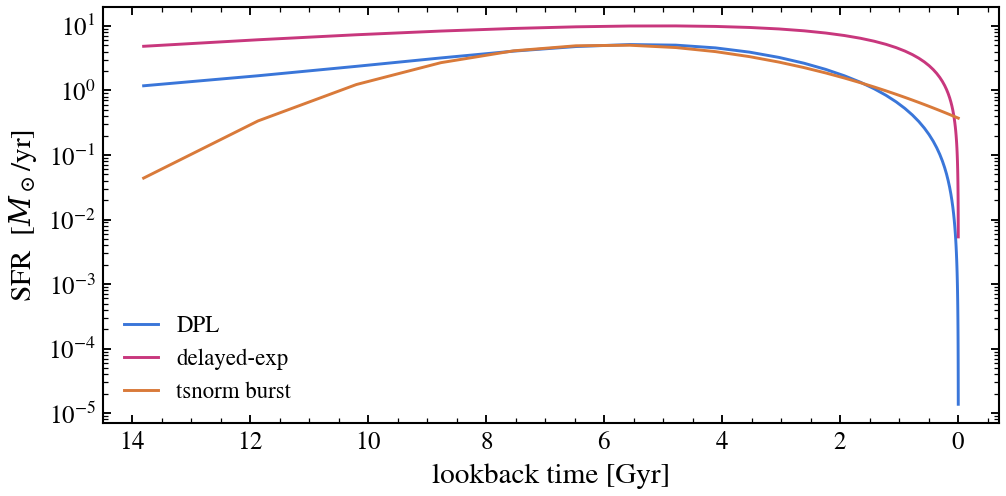

In [7]:
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "wise_w1"])
)


def _build_sfh(sfh_factory):
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        sfh=sfh_factory(defaults=FIXED),
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED},
        neb={"type": "none"},
        redshift=0.05,
    )


fig, ax = plt.subplots(figsize=(7, 3.6))
for name, factory, color in [
    ("DPL", builders.sfh.dpl, "#3a76d9"),
    ("delayed-exp", builders.sfh.dexp, "#c8377d"),
    ("tsnorm burst", builders.sfh.tsnorm, "#d97a3a"),
]:
    m = _build_sfh(factory)
    p = m.spec.sample(jax.random.PRNGKey(0))
    p = {**m.spec.get_fixed_values(), **p}
    s = m.predict_state(p)
    lbt_gyr = np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9
    sfr = np.asarray(s.derived["sfr_history"])
    ax.plot(lbt_gyr, sfr, color=color, lw=1.4, label=name)
ax.invert_xaxis()
ax.set_xlabel("lookback time [Gyr]")
ax.set_ylabel(r"SFR  [$M_\odot$/yr]")
ax.set_yscale("log")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_sfh_variants.png", dpi=300, bbox_inches="tight")

## Dust laws and IR templates

Attenuation laws — Calzetti, Cardelli (MW/LMC/SMC), Prevot SMC, Li 2008,
Witt & Gordon 2000, Conroy/Charlot–Fall variants — and IR re-emission
templates (Dale 2014, Draine–Li, THEMIS, Astrodust, BOSA, Casey 2012,
modified blackbody) all live under `tengri.components.dust`.

In [8]:
tengri.list_dust_laws()

name,status,citation,short_doc
calzetti,production,"Calzetti et al. 2000 (ApJ 533, 682)",Calzetti et al. starburst attenuation (R_V=4.05)
cardelli,production,"Cardelli et al. 1989 (ApJ 345, 245) MW extinction",Cardelli et al. MW extinction (parameterized R_V)
conroy2010,production,"Conroy et al. 2010 (ApJ 708, 58)",Conroy+10 mixed MW + power-law (FSPS default)
d03_mwrv31,production,"Draine 2003 (ARA&A 41, 241)",Draine 2003 MW R_V=3.1 grain model attenuation
hd23_mwrv31,production,"Hensley & Draine 2023 (ApJ 948, 55)",Hensley & Draine 2023 astrodust+PAH grain model
kriek_conroy,production,"Kriek & Conroy 2013 (ApJL 775, L16)",Kriek & Conroy modified Calzetti + bump + slope
leitherer02,production,"Leitherer et al. 2002 (ApJS 140, 303)",Leitherer et al. UV starburst attenuation
li08,production,"Li et al. 2008 (ApJ 685, 1046)",Li et al. analytical flexible attenuation curve
lmc,production,"Pei 1992 (ApJ 395, 130) LMC","LMC extinction (Pei 1992, weak bump)"
narayanan_z,production,"Narayanan et al. 2018 (ApJ 869, 70)",Narayanan et al. z-dependent attenuation (SIMBA)


In [9]:
tengri.list_dust_emission_models()

name,status,citation,short_doc
astrodust,experimental,"Hensley & Draine 2023 (ApJ 948, 55)",Astrodust + PAH unified grain model
bosa,experimental,Boquien et al. 2019 (CIGALE BOSA grids),BOSA dust SED templates
dale2014,production,"Dale et al. 2014 (ApJ 784, 83)",SFR-driven empirical IR template family (alpha_sf)
dl07,production,"Draine & Li 2007 (ApJ 657, 810)","Diffuse + PAH grain mixture, Umin/Umax/qpah"
dl14,production,"Draine et al. 2014 (ApJ 780, 172)",Updated DL with extended PAH and silicate features
mbb,production,"Casey 2012 (MNRAS 425, 3094)",Single-temperature modified blackbody (analytic)
themis,experimental,"Jones et al. 2017 (A&A 602, A46)",THEMIS amorphous-carbon grain model


## Nebular backends

- **`cue`** — neural emulator on Cloudy 17.03 (Li+2024). Fast, smooth,
  requires bare-stellar SSP.
- **`ssp`** — baked-in nebular contribution from a wNE SSP grid.
  Cheapest, locked to grid choices.
- **`cloudy`** — direct Cloudy evaluation. Accurate, slow.
- **`none`** — disable.

In [10]:
tengri.list_nebular_backends()

name,status,citation,short_doc
baked_in,production,DSPS / FSPS SSP-internal,Emission baked into SSP grid; zero free params
cue,production,Li+2024 (CUE neural emulator),Neural-network Cloudy emulator
cloudy_grid,production,Byler+2017 grids,Trilinear interp on Cloudy grid
cb19,experimental,Charlot & Bruzual 2019,Precomputed CB19 nebular grid


## AGN composables

AGN is built from four orthogonal pieces — disc, torus, lines, FeII —
each with its own registry. `recipes.agn_panchromatic()` is one
stable composition.

In [11]:
tengri.list_agn_models()

name,status,citation,short_doc,param_details
adaf,production,"Mahadevan 1997 (ApJ 477, 585)",ADAF + truncated disc + simple torus (low-luminosity),"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_log_mbh', 'default': 'Fixed(7.0)', 'description': 'AGN black hole mass log10(M_BH/Msun)'}, {'name': 'agn_log_ledd', 'default': 'Fixed(-1.0)', 'description': 'AGN Eddington ratio log10(L/L_Edd)'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor (fraction of L_bol re-emitted by torus)'}, {'name': 'agn_T_torus', 'default': 'Fixed(1000.0)', 'description': 'AGN torus temperature (K)'}]"
cat3d_wind,production,"Hönig & Kishimoto 2017 (ApJL 838, L20)",Power-law disc + CAT3D-Wind clumpy torus,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor (fraction of L_bol re-emitted by torus)'}]"
composable,production,(no single paper — block recipe of registered tengri AGN blocks),Composable AGN: pick one block per stage (disc/lines/feii/torus/atten),"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}]"
grahsp,production,,,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_grahsp_uvslope', 'default': 'Fixed(0.0)', 'description': 'GRAHSP BBB UV power-law index alpha_1 (paper uvslope). Typical 0; must satisfy uvslope > plslope.'}, {'name': 'agn_grahsp_plslope', 'default': 'Fixed(-1.7)', 'description': 'GRAHSP BBB optical power-law index alpha_2 (paper plslope). Typical -2.7 to -1; must satisfy uvslope > plslope.'}, {'name': 'agn_grahsp_plbendloc_nm', 'default': 'Fixed(100.0)', 'description': 'GRAHSP BBB bend wavelength lambda_break [nm] (paper plbendloc). Typical 50-200 nm.'}, {'name': 'agn_grahsp_plbendwidth', 'default': 'Fixed(1.0)', 'description': 'GRAHSP BBB bend width Lambda [dex] (paper plbendwidth). Typical 0.1-10.'}, {'name': 'agn_grahsp_cutoff_nm', 'default': 'Fixed(10000.0)', 'description': 'GRAHSP BBB IR cutoff [nm]; -1 disables (paper cutoff). Default 1e4.'}, {'name': 'agn_grahsp_a_lines', 'default': 'Fixed(1.0)', 'description': 'GRAHSP line strength scale (paper Alines). Typical 0.3-20.'}, {'name': 'agn_grahsp_a_feii', 'default': 'Fixed(5.0)', 'description': 'GRAHSP FeII forest strength relative to broad H-beta (paper AFeII). Typical 2-10.'}, {'name': 'agn_grahsp_linewidth_kms', 'default': 'Fixed(5000.0)', 'description': 'GRAHSP emission-line FWHM [km/s] (paper Wline). Typical 100-30000.'}, {'name': 'agn_grahsp_fcov', 'default': 'Fixed(0.4)', 'description': 'GRAHSP torus covering factor at 12 um (paper fcov). Typical 0.05-0.95; relates to Stalevski+2016 geometric f_cov.'}, {'name': 'agn_grahsp_si', 'default': 'Fixed(0.0)', 'description': 'GRAHSP Si feature strength (paper Si). Negative=absorption, positive=emission. Typical -4 to +4.'}, {'name': 'agn_grahsp_cool_lam_um', 'default': 'Fixed(17.0)', 'description': 'GRAHSP cool dust peak wavelength [um] (p

## Recipes — five curated starting points

In [12]:
print(list(recipes.__all__))

['agn_panchromatic', 'dust_demo', 'mock_recovery_minimal', 'quiescent_z0', 'star_forming_photometry', 'stochastic_sfh_jwst']


In [13]:
recipes.star_forming_photometry()

{'sfh': {'type': 'dpl', '*': FREE},
 'dust': {'type': 'two_component',
  '*': FREE,
  'law_bc': 'calzetti',
  'law_diff': 'calzetti',
  'emission': {'type': 'dale2014', '*': FIXED}},
 'neb': {'type': 'cue', '*': FIXED},
 'redshift': Uniform(0.01, 6.0),
 'apply_igm': True,
 'approx': WavePrecomp(n_z=100, z_min=None, z_max=None, catalog_z_range=None)}

## Inference backends

The `status` column reports whether each backend's dependencies are
importable. Compatibility against a specific model is rechecked at
`Fitter.run` time.

In [14]:
tengri.list_inference_methods()

name,tier,status,short_doc
laplace,primary,ok,"Laplace approximation around the MAP (cold ~5-9s, warm ~1-2s, ~3 GB)"
map,primary,ok,Adam MAP optimization
mcmc,primary,ok,"Auto MCMC: NUTS for low-D, raytrace for high-D"
mcmc_hmc,primary,ok,"Hamiltonian Monte Carlo (cold ~21s, ~5 GB on D=6-7). Convergence-validated only with dense_mass_matrix=True, n_warmup≥1000, n_leapfrog_steps≥20 on D=6 DPL (R-hat 1.008, ESS 411). Default n_warmup=300 / dense=True gives R-hat ≫ 1 — do not lower the warmup for science."
mcmc_nuts,primary,ok,No-U-Turn Sampler (cold ~90s at D=6 DPL; warmup blows past 5 min on dense_basis D=7 — prefer mcmc_hmc or mcmc_ghmc for dense_basis SFH)
mcmc_raytrace,primary,ok,Ray-tracing ensemble sampler (high-D)
vi,primary,ok,"NIFTy geoVI variational inference (cold ~100s, ~20 GB RSS at D=6-7 — memory-heavy; consider mcmc_ghmc for faster turnaround on D<10)"
vi_nonlinear_fast,primary,ok,NIFTy geoVI without Python logging
mcmc_adjusted_mclmc,experimental,ok,"Adjusted microcanonical Langevin (cold ~60s, ~3x compile premium over mclmc)"
mcmc_dynamic_hmc,experimental,ok,"Dynamic HMC — fast (cold ~19s) but chains under-mix at default settings (R-hat ≈ 1.11-1.25, ESS ≈ 1-30 on D=6-7 mocks, 1000 warmup + 2000 samples). Needs tuning before science use."


## Parameter and physics provenance

Two introspection surfaces close the loop:
`model.spec.summary()` tags every parameter with where its value came
from (`[user]` / `[* FREE]` / `[* FIXED]` / `[default]`).
`citations.collect_citations(model)` returns the bibliography of every
physics ingredient.

In [15]:
example = SEDModel.build(ssp_data=ssp, observation=obs, **recipes.star_forming_photometry())
example.spec.summary()

W0524 12:39:14.787390 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:14.821899 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:14.851015 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:39:15.051462 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.164199 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.207276 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.210910 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.214020 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.241916 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.246453 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:39:15.265761 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.301310 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.304725 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.336745 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.340253 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.451353 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0524 12:39:15.474261 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.479834 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0524 12:39:15.484514 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


/Users/suchethacooray/Projects/tengri/src/tengri/components/nebular/ionizing_spectrum.py:96: RuntimeWarning: invalid value encountered in scalar divide
  np.abs((_seg_wave[-1] ** params[0] - _seg_wave[0] ** params[0]) / params[0])


Parameters  SFH: dpl
──────────────────────────────────────────────────────────────────
  Dimensions:  8 free, + 29 fixed
  Modules:     nebular=cue, dust_emission=dale2014, igm, dust_law=calzetti/calzetti

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_tau_bc                      Uniform(0.0, 4.0)          [0, 4]                 [* FREE]
  dust_tau_diff                    Uniform(0.0, 3.0)          [0, 3]                 [* FREE]
  met_logzsol                      Uniform(-2.0, 0.2)         [-2, 0.2]              [* FREE]
  redshift                         Uniform(0.01, 6.0)         [0.01, 6]              [user]
  sfh_dpl_alpha                    Uniform(0.1, 5.0)          [0.1, 5]               [* FREE]
  sfh_dpl_beta                     Uniform(0.1, 3.0)          [0.1, 3]               [* FREE]
  sfh_dpl_log_peak_sfr             Uniform(-1.

W0524 12:39:21.587021 3193429 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


In [16]:
bib = citations.collect_citations(example)
citations.print_citations(example)

Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
       code: jax-ml/jax

  [3] Hearin et al. (2023)  —  Differentiable stellar population synthesis engine
       {DSPS: Differentiable stellar population synthesis}
       DOI: 10.1093/mnras/stad456   arXiv: 2112.06830   code: ArgonneCPAC/dsps

  [4] Carnall et al. (2018)  —  Reference SED fitting framework (BAGPIPES)
       {Inferring the star formation histories of massive quiescent galaxies with BAGPIPES: evidence for multiple quenching mechanisms}
       DOI: 10.1093/mnras/sty2169   arXiv: 1712.04452   code: ACCarnall/bagpipes

  [5] Dale

Export to BibTeX in one call:

In [17]:
bibtex = citations.citations_bibtex(example)
print(bibtex[:600], "…")

@article{Cooray_2026,
  author = {{Cooray}, Suchetha},
  title = {{tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}},
  year = {2026},
  journal = {in preparation},
}

@article{Jamesbradbury_2018,
  author = {James Bradbury and Roy Frostig and Peter Hawkins and Matthew James Johnson and Chris Leary and Dougal Maclaurin and George Necula and Adam Paszke and Jake Vander{P}las and Skye Wanderman-{M}ilne and Qiao Zhang},
  title = {{JAX}: composable transformations of {P}ython+{N}um{P}y programs},
  year = {2018},
}

@a …


## Cache and memory

- **`tengri.lean`** — context manager / default mode. Drops the
  per-Fitter JIT engine after each `run` to release graph memory.
- **`tengri.persistent`** — opposite mode. Keep the engine for
  repeated same-shape fits (population sweep, MCMC restart).
- **`tengri.gc`** — one-shot collect: clears shared caches and asks
  XLA to release the device.
- **`tengri.clear_shared_caches()`** — full reset for clean
  benchmarking.

The persistent JAX compile cache (`~/.cache/tengri_jax_cache`,
auto-enabled by `import tengri`) is independent of these — it survives
process restarts.

## Cross-namespace search

`tengri.search("term")` queries every registry at once.

In [18]:
tengri.search("Calzetti")

name,status,citation,short_doc
calzetti,production,"Calzetti et al. 2000 (ApJ 533, 682)",Calzetti et al. starburst attenuation (R_V=4.05)
kriek_conroy,production,"Kriek & Conroy 2013 (ApJL 775, L16)",Kriek & Conroy modified Calzetti + bump + slope
noll09,production,"Noll et al. 2009 (A&A 507, 1793)",Noll et al. modified Calzetti + L02 + bump + slope
salim,production,"Salim et al. 2018 (ApJ 859, 11)",Salim et al. modified Calzetti (DSPS default)
salim_sbl18,production,"Salim et al. 2018 (ApJ 859, 11)","Salim, Boquien & Lee modified Calzetti + L02"


## Sub-namespaces — where to look for what

- **`tengri.cosmology`** — Planck 2018 distance and time integrals
  (`luminosity_distance_mpc`, `age_at_z`, …).
- **`tengri.units`** — F_ν ↔ L_ν ↔ AB-mag conversions, vacuum-air, Jy.
- **`tengri.plot`** — `plot_sed_fit`, `plot_sfh`, `plot_corner_comparison`,
  `setup_style`, `diagnostics_table`. Re-exports of
  `tengri.analysis.plotting`.
- **`tengri.observation`** — `Photometry`, `Spectroscopy`, `Observation`,
  `NoiseModel`, `LineList`, filter loaders.
- **`tengri.inference`** — `Fitter`, `CatalogFitter`, `PopulationFitter`,
  `VIConfig`, `InferenceContext`.
- **`tengri.results`** — `Posterior`, `CatalogPosterior`,
  `PopulationPosterior`, `FitResult`, `MockData`, `Provenance`,
  `generate_mock`.
- **`tengri.config`** — `SEDModelConfig`, `SFHConfig`, `DustConfig`,
  `NebularConfig`, `AGNConfig`.
- **`tengri.protocols`** — Protocol shapes (`SEDComponent`, `Likelihood`,
  `ObservationModel`, `DerivedKey`, `ForwardState`).
- **`tengri.builders`** — config-dict factories with introspectable
  signatures (`builders.sfh.*`, `builders.dust.*`, `builders.neb.*`,
  `builders.agn.*`, `builders.igm.*`).
- **`tengri.citations`** — `Bibliography`, `Citation`,
  `collect_citations`, `citations_report`, `citations_bibtex`,
  `print_citations`, `print_bibtex`, `paper_citation`.

From here: try `tengri.help()` for topic-indexed pointers, or
`dir(tengri.components.<area>)` for any physics sub-namespace.